import the libraries

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

upload the sqlite3 file

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving irisdatabase.sqlite to irisdatabase.sqlite


connecting to sqlite database

In [ ]:
conn=sqlite3.connect("irisdatabase.sqlite")

check table names

In [ ]:
tables=pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';",conn)
print(tables)

   name
0  Iris


scattter the iris dataset

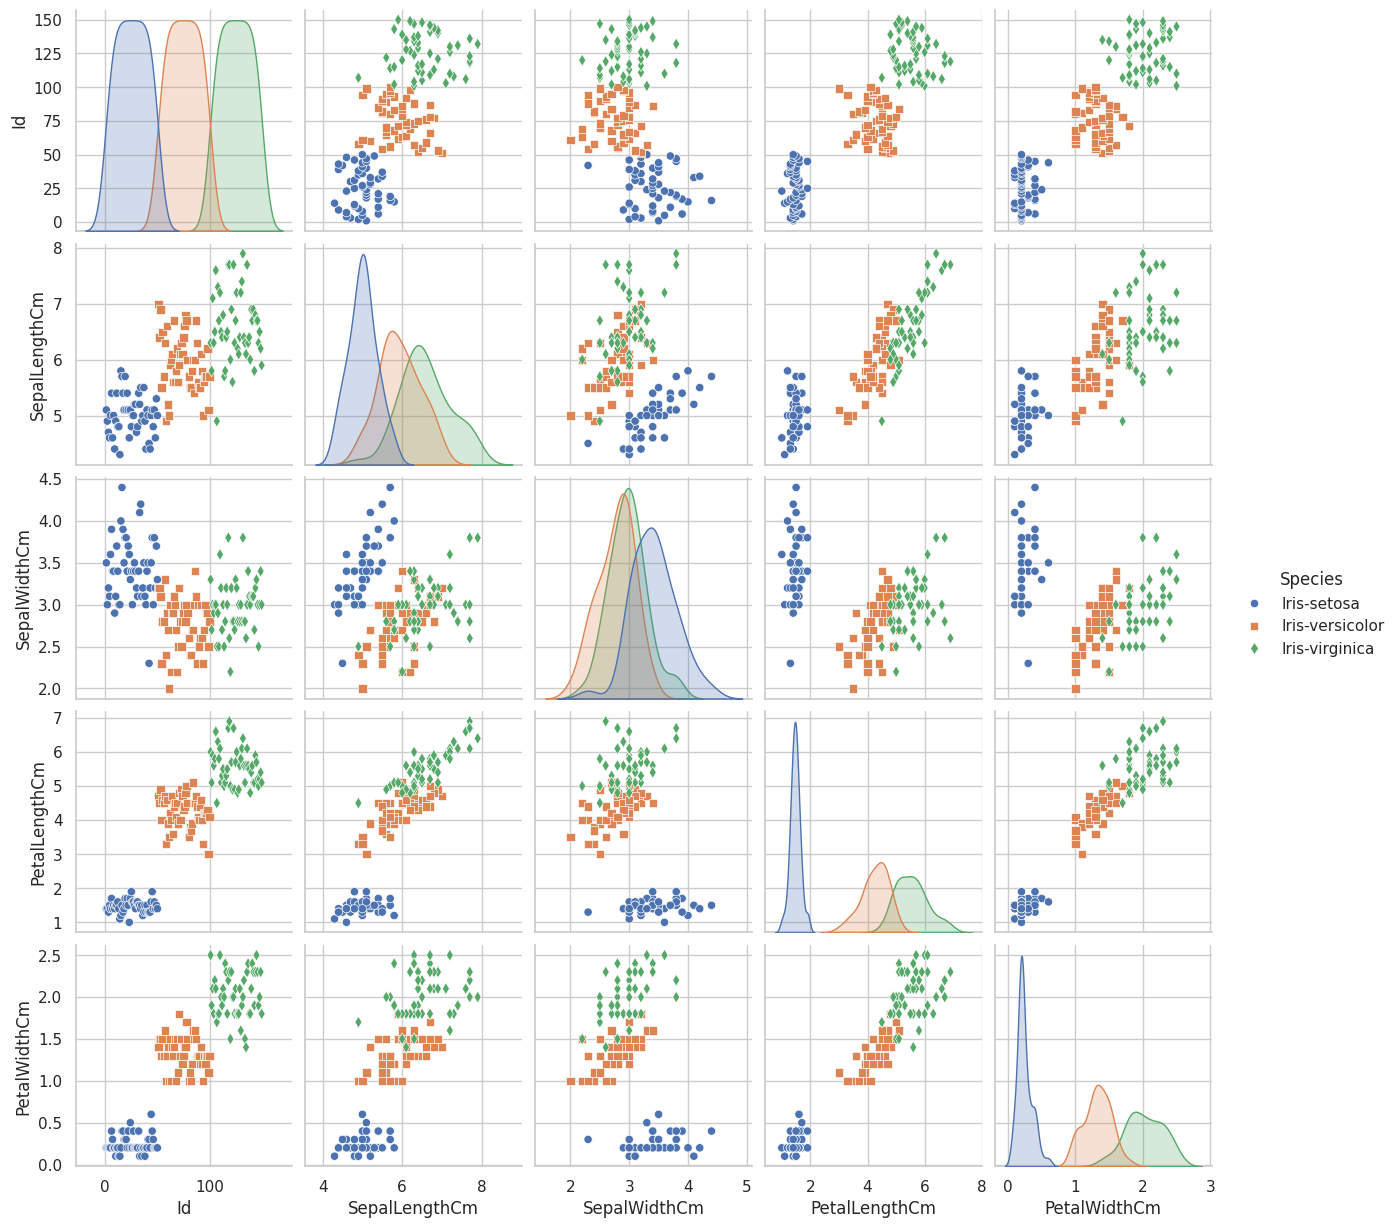

In [ ]:
sns.set(style="whitegrid")
sns.pairplot(df,hue="Species",markers=["o","s","d"])
plt.show()

loading the dataset table

In [ ]:
df=pd.read_sql("SELECT *FROM iris",conn)
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


prepare feature x and target y

In [ ]:
x=df.drop('Species',axis=1)
y=df['Species']

split dataset into train and test

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

standard features

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

create knn classifier and train

In [ ]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

make predictions

In [ ]:
y_pred=knn.predict(x_test)

evaluate model

In [ ]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("classification_report",classification_report(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

Accuracy 1.0
classification_report                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

confusion_matrix [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


close the connection

In [ ]:
conn.close()